# Exploratory data analysis


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pvforecast import evaluation, preprocessing
from pvforecast.config import FIGURES_DIR, MODEL_INPUT, RAW_DIR

df = pd.read_parquet(MODEL_INPUT)
pv = df["pv_mwh"]
local = df.index.tz_convert("Europe/Berlin")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Zeitraum: {df.index.min():%Y-%m-%d} bis {df.index.max():%Y-%m-%d}")
print(f"Stunden: {len(df):,}  |  Spalten: {df.shape[1]}")
print(f"NaN gesamt: {int(df.isna().sum().sum())}")
print(f"\nSpalten: {df.columns.tolist()}")

Zeitraum: 2014-12-31 bis 2025-12-31
Stunden: 96,433  |  Spalten: 8
NaN gesamt: 0

Spalten: ['pv_mwh', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'temperature_2m', 'cloud_cover', 'relative_humidity_2m', 'wind_speed_10m']


## Descriptive statistics

In [2]:
print(df.describe().T.round(2).to_string())

                        count     mean      std    min    25%     50%      75%       max
pv_mwh                96433.0  5481.89  8719.51   0.00   0.84  160.36  8452.59  52132.25
shortwave_radiation   96433.0   132.14   195.42   0.00   0.00    7.00   214.40    882.00
direct_radiation      96433.0    78.05   134.77   0.00   0.00    1.00   102.60    749.00
diffuse_radiation     96433.0    54.10    71.43   0.00   0.00    5.40   101.00    338.80
temperature_2m        96433.0    10.57     7.64 -13.94   4.58   10.10    16.14     36.04
cloud_cover           96433.0    66.57    26.36   0.00  49.80   71.60    88.40    100.00
relative_humidity_2m  96433.0    76.51    15.40  16.20  67.60   80.80    88.60     99.60
wind_speed_10m        96433.0    11.53     4.76   2.20   8.08   10.50    13.90     40.88


## Target variable over time

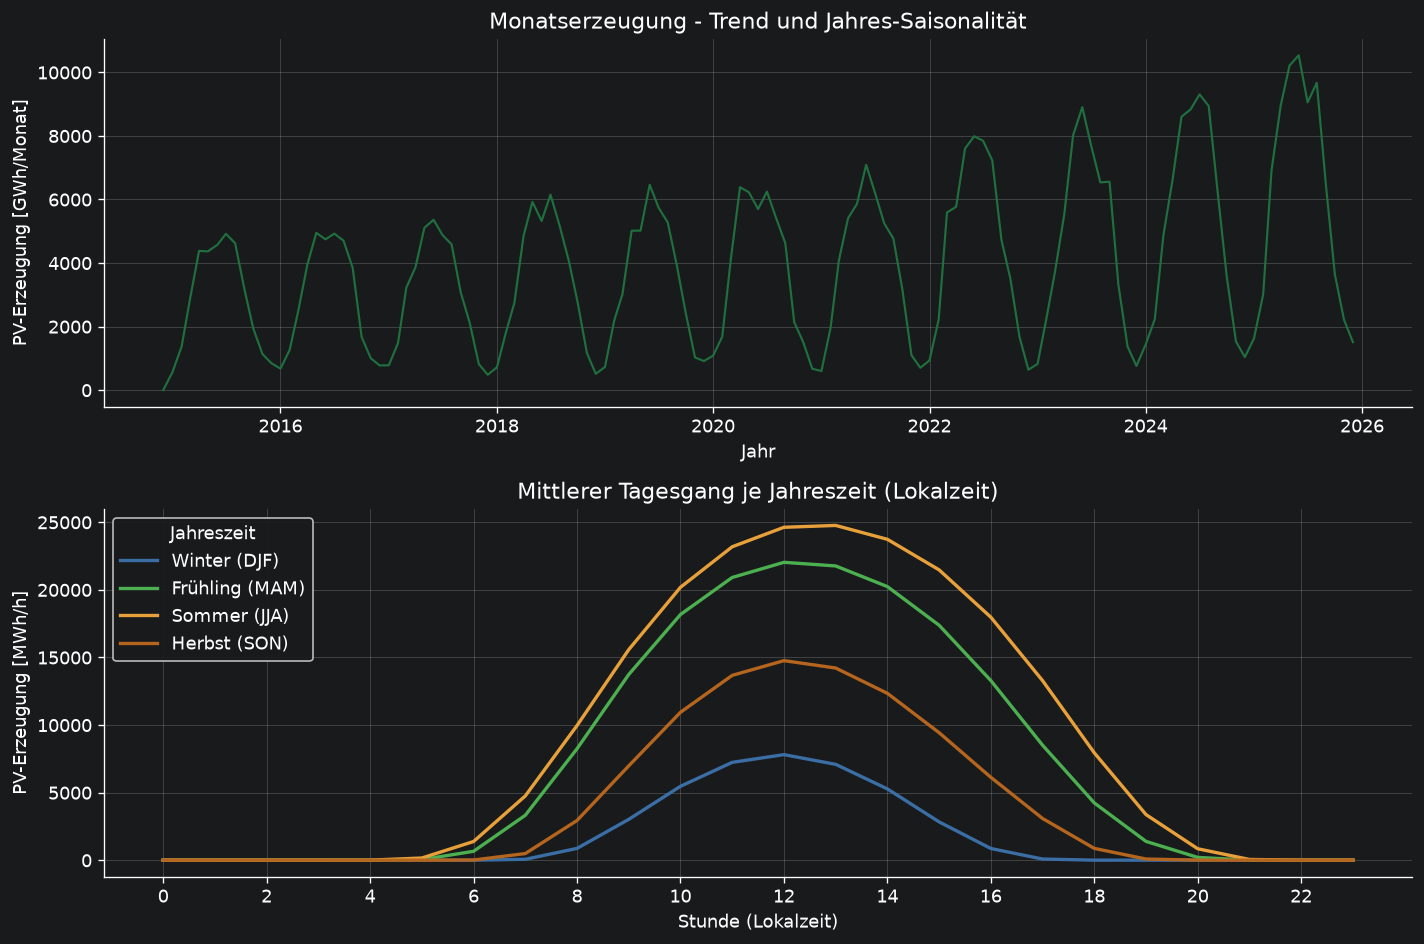

In [3]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 8))

# (a) Monthly energy over all years -> trend and annual seasonality
monthly = pv.resample("MS").sum() / 1e3  # MWh -> GWh
ax_top.plot(monthly.index, monthly.values, color="#1f6f3f", lw=1.3)
ax_top.set_title("Monatserzeugung - Trend und Jahres-Saisonalität")
ax_top.set_ylabel("PV-Erzeugung [GWh/Monat]")
ax_top.set_xlabel("Jahr")

# (b) Mean daily cycle per meteorological season -> robust day shape
season = local.month % 12 // 3  # 0=Winter, 1=Frühling, 2=Sommer, 3=Herbst
season_names = ["Winter (DJF)", "Frühling (MAM)", "Sommer (JJA)", "Herbst (SON)"]
season_colors = ["#3b6ea5", "#4caf50", "#e8a13a", "#b5651d"]
prof = pd.DataFrame({"pv": pv.values, "hour": local.hour, "season": season})
for s in range(4):
    m = prof[prof.season == s].groupby("hour")["pv"].mean()
    ax_bot.plot(m.index, m.values, label=season_names[s], color=season_colors[s], lw=2)
ax_bot.set_title("Mittlerer Tagesgang je Jahreszeit (Lokalzeit)")
ax_bot.set_ylabel("PV-Erzeugung [MWh/h]")
ax_bot.set_xlabel("Stunde (Lokalzeit)")
ax_bot.set_xticks(range(0, 24, 2))
ax_bot.legend(title="Jahreszeit", loc="upper left", framealpha=0.9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_zielgroesse_zeit.png")
plt.show()

## Annual generation and hourly peak

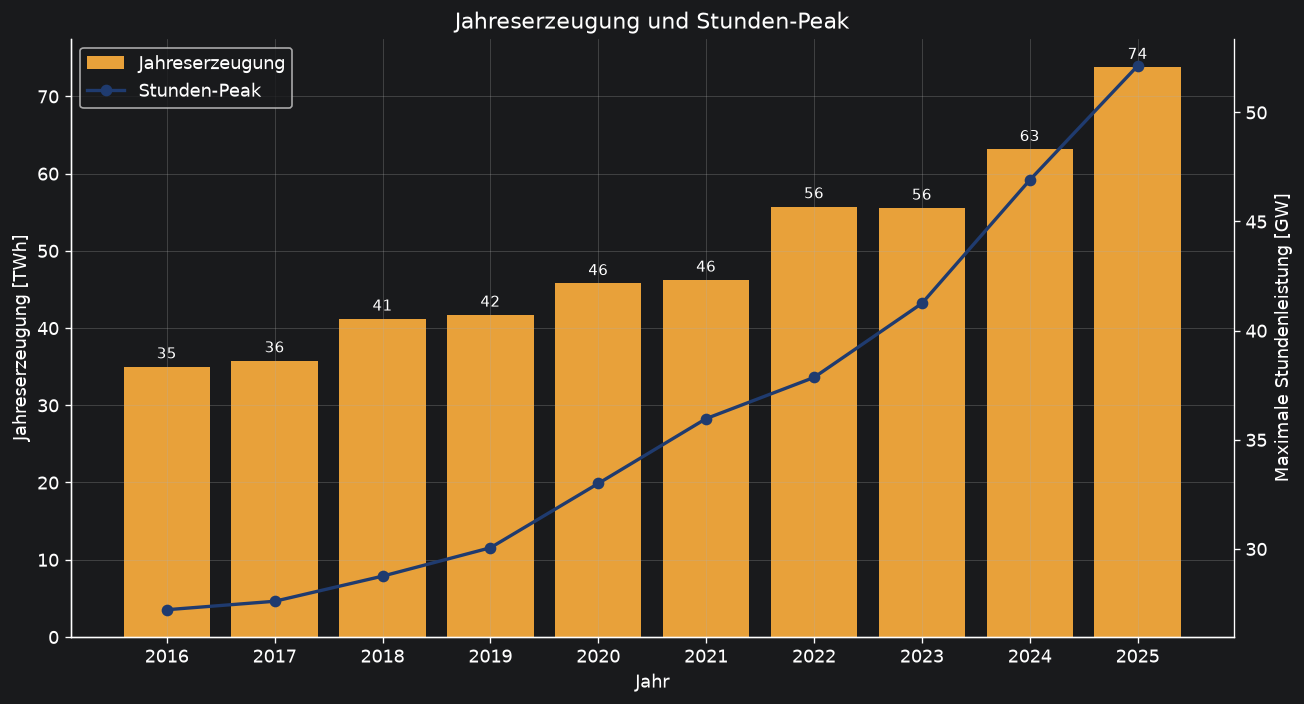

In [4]:
year = local.year
full_years = sorted(set(year))[1:-1] if len(set(year)) > 2 else sorted(set(year))
gen_twh = (pv.groupby(year).sum() / 1e6).loc[full_years]  # MWh -> TWh
peak_gw = (pv.groupby(year).max() / 1e3).loc[full_years]  # MWh/h -> GW

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(gen_twh.index, gen_twh.values, color="#e8a13a", label="Jahreserzeugung")
ax.set_ylabel("Jahreserzeugung [TWh]")
ax.set_xlabel("Jahr")
ax.set_title("Jahreserzeugung und Stunden-Peak")
ax.set_xticks(gen_twh.index)
for x, v in gen_twh.items():
    ax.text(x, v + 0.6, f"{v:.0f}", ha="center", va="bottom", fontsize=9)

ax2 = ax.twinx()
ax2.spines["right"].set_visible(True)
ax2.grid(False)
ax2.plot(peak_gw.index, peak_gw.values, color="#1f3b6f", marker="o", lw=2)
ax2.set_ylabel("Maximale Stundenleistung [GW]")

h1, l1 = ax.get_legend_handles_labels()
ax.legend(h1 + ax2.get_lines(), l1 + ["Stunden-Peak"], loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_jahreserzeugung_peak.png")
plt.show()

## Hour by month

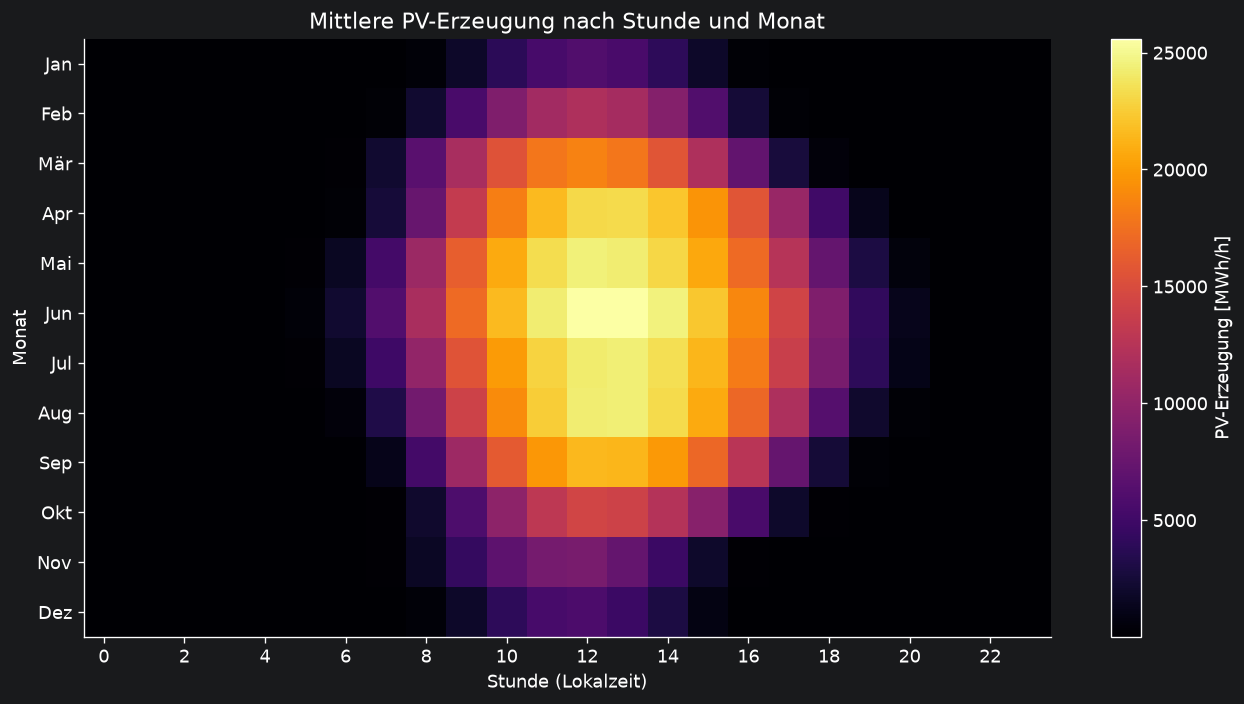

In [5]:
hm = pd.DataFrame({"pv": pv.values, "hour": local.hour, "month": local.month})
grid = hm.groupby(["month", "hour"])["pv"].mean().unstack("hour")

fig, ax = plt.subplots(figsize=(11, 6))
mesh = ax.pcolormesh(
    grid.columns, grid.index, grid.values, cmap="inferno", shading="nearest"
)
ax.set_title("Mittlere PV-Erzeugung nach Stunde und Monat")
ax.set_xlabel("Stunde (Lokalzeit)")
ax.set_ylabel("Monat")
ax.set_xticks(range(0, 24, 2))
ax.set_yticks(range(1, 13))
ax.set_yticklabels(
    ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun", "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]
)
ax.invert_yaxis()
ax.grid(False)
fig.colorbar(mesh, ax=ax).set_label("PV-Erzeugung [MWh/h]")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_heatmap_stunde_monat.png")
plt.show()

## Distribution of the target

Most hours are night. The models are scored on daylight hours only, so both views
matter.

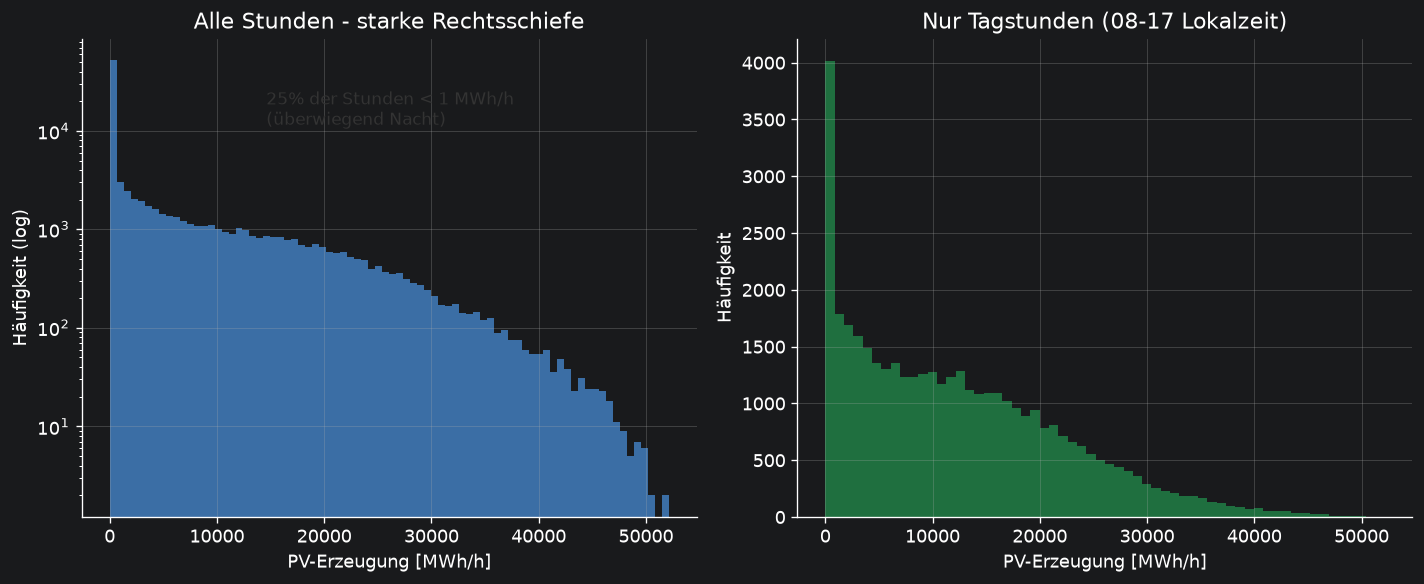

In [6]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5))

ax_l.hist(pv.values, bins=80, color="#3b6ea5")
ax_l.set_yscale("log")
ax_l.set_title("Alle Stunden - starke Rechtsschiefe")
ax_l.set_xlabel("PV-Erzeugung [MWh/h]")
ax_l.set_ylabel("Häufigkeit (log)")
near_zero = float((pv < 1).mean())
ax_l.annotate(
    f"{near_zero:.0%} der Stunden < 1 MWh/h\n(überwiegend Nacht)",
    xy=(0.30, 0.82),
    xycoords="axes fraction",
    ha="left",
    fontsize=10,
    color="#333",
)

day_mask = (local.hour >= 8) & (local.hour <= 17)
ax_r.hist(pv.values[day_mask], bins=60, color="#1f6f3f")
ax_r.set_title("Nur Tagstunden (08-17 Lokalzeit)")
ax_r.set_xlabel("PV-Erzeugung [MWh/h]")
ax_r.set_ylabel("Häufigkeit")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_verteilung.png")
plt.show()

## Capacity drift and the choice of normaliser

The fleet grew from about 40 to over 100 GW. A capacity factor normalised on
nameplate power therefore drifts even under identical irradiance. The rolling
empirical capacity is the alternative the pipeline uses.

In [7]:
capacity_monthly = preprocessing.load_capacity(
    RAW_DIR / "capacity_energycharts_solar_2002-2026.csv"
)

# Monthly GW -> hourly MW on the PV grid
ac_mw = (
    capacity_monthly["solar_ac_gw"]
    .reindex(capacity_monthly.index.union(pv.index))
    .interpolate("time")
    .reindex(pv.index)
    * 1e3
)
cf_nameplate = pv / ac_mw

cap_roll = preprocessing.rolling_capacity(pv)
cf_rolling = preprocessing.capacity_factor(pv, cap_roll)

print(f"Installiert {pv.index[0]:%Y-%m}: {ac_mw.iloc[0] / 1e3:.1f} GW AC")
print(f"Installiert {pv.index[-1]:%Y-%m}: {ac_mw.iloc[-1] / 1e3:.1f} GW AC")
print(f"Rollierende Kapazität ab: {cap_roll.first_valid_index():%Y-%m-%d}")
print(f"Modellstart nach Warm-up: {preprocessing.DATA_START:%Y-%m-%d}")

Installiert 2014-12: 35.8 GW AC
Installiert 2025-12: 108.9 GW AC
Rollierende Kapazität ab: 2015-01-02
Modellstart nach Warm-up: 2016-01-01


In [8]:
# Same irradiance conditions every year: clear summer midday hours
clear_midday = (
    df.index.month.isin([5, 6, 7])
    & df.index.hour.isin([10, 11, 12])
    & (df["shortwave_radiation"] > 600)
)
selected = pd.DataFrame({"nameplate": cf_nameplate, "rolling": cf_rolling})[
    clear_midday
].loc[preprocessing.DATA_START :]

annual = selected.groupby(selected.index.year).agg(["mean", "count"])
annual.columns = ["CF Nennleistung", "n", "CF rollierend", "n2"]
annual = annual[["n", "CF Nennleistung", "CF rollierend"]]
nameplate, rolling = annual["CF Nennleistung"], annual["CF rollierend"]

print(annual.round(3).to_string())
print(
    f"\nNennleistung: {nameplate.iloc[0]:.3f} -> {nameplate.iloc[-1]:.3f} "
    f"({nameplate.iloc[-1] / nameplate.iloc[0] - 1:+.0%})"
)
print(
    f"Rollierend:   {rolling.iloc[0]:.3f} -> {rolling.iloc[-1]:.3f} "
    f"({rolling.iloc[-1] / rolling.iloc[0] - 1:+.0%}), "
    f"Spanne {rolling.min():.2f}-{rolling.max():.2f}"
)

        n  CF Nennleistung  CF rollierend
time                                     
2016  109            0.571          0.903
2017  132            0.576          0.921
2018  178            0.573          0.913
2019  157            0.549          0.900
2020  116            0.549          0.894
2021  117            0.524          0.908
2022  166            0.528          0.935
2023  168            0.480          0.923
2024  125            0.448          0.966
2025  125            0.416          0.914

Nennleistung: 0.571 -> 0.416 (-27%)
Rollierend:   0.903 -> 0.914 (+1%), Spanne 0.89-0.97


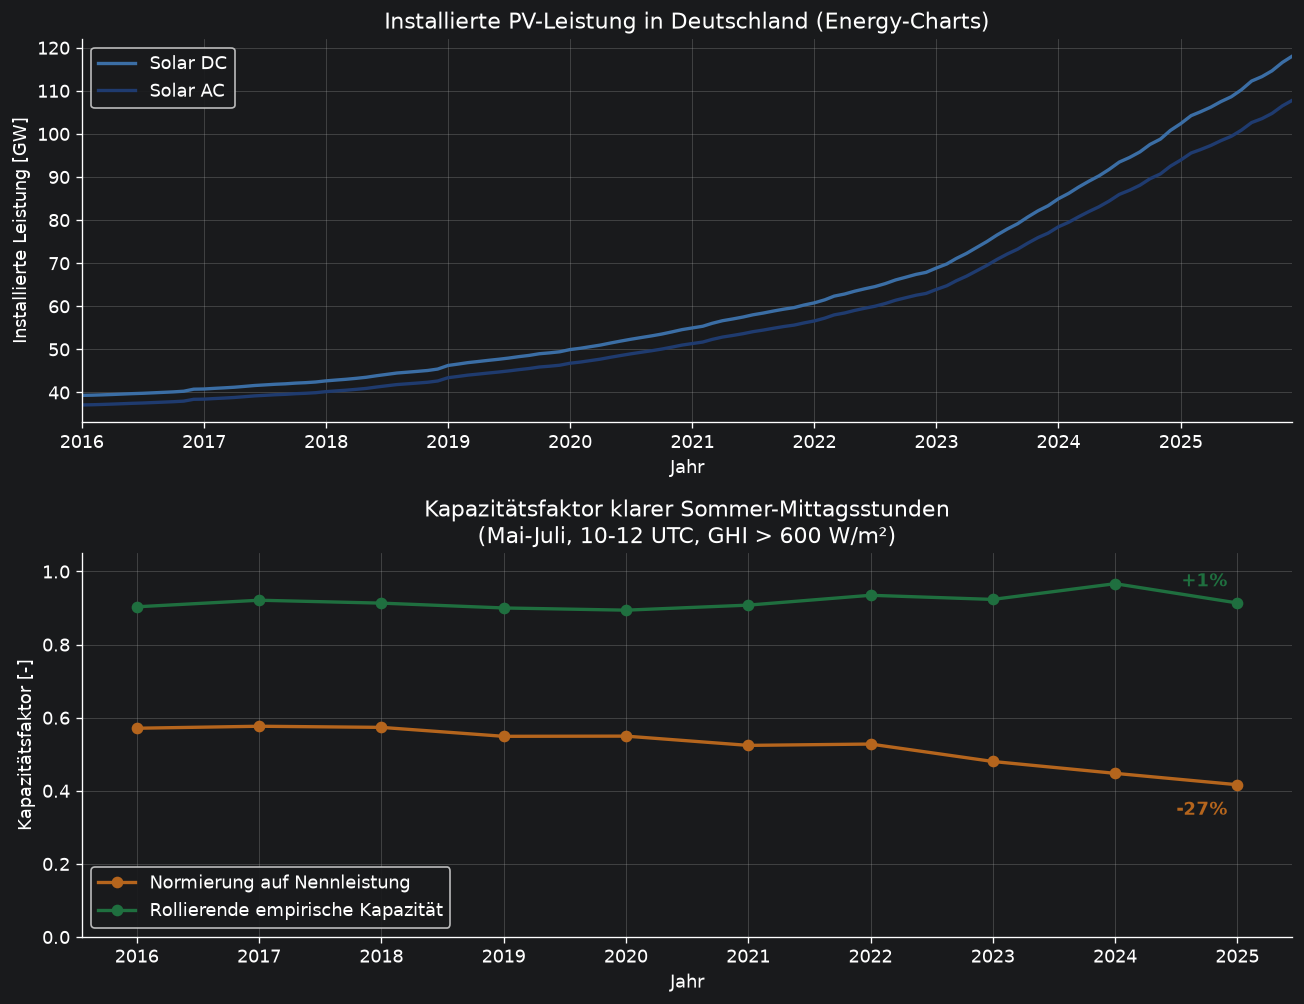

In [9]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 8.5))

window = capacity_monthly.loc[preprocessing.DATA_START : df.index.max()]
ax_top.plot(
    window.index, window["solar_dc_gw"], color="#3b6ea5", lw=2, label="Solar DC"
)
ax_top.plot(
    window.index, window["solar_ac_gw"], color="#1f3b6f", lw=2, label="Solar AC"
)
ax_top.set_title("Installierte PV-Leistung in Deutschland (Energy-Charts)")
ax_top.set_ylabel("Installierte Leistung [GW]")
ax_top.set_xlabel("Jahr")
ax_top.set_xlim(window.index.min(), window.index.max())
ax_top.legend(loc="upper left", framealpha=0.9)

ax_bot.plot(
    nameplate.index,
    nameplate.values,
    color="#b5651d",
    marker="o",
    lw=2,
    label="Normierung auf Nennleistung",
)
ax_bot.plot(
    rolling.index,
    rolling.values,
    color="#1f6f3f",
    marker="o",
    lw=2,
    label="Rollierende empirische Kapazität",
)
ax_bot.set_title(
    "Kapazitätsfaktor klarer Sommer-Mittagsstunden\n"
    "(Mai-Juli, 10-12 UTC, GHI > 600 W/m²)"
)
ax_bot.set_ylabel("Kapazitätsfaktor [-]")
ax_bot.set_xlabel("Jahr")
ax_bot.set_ylim(0, 1.05)
ax_bot.set_xticks(nameplate.index)
ax_bot.legend(loc="lower left", framealpha=0.9)
for series, color, offset in ((nameplate, "#b5651d", -18), (rolling, "#1f6f3f", 10)):
    ax_bot.annotate(
        f"{series.iloc[-1] / series.iloc[0] - 1:+.0%}",
        xy=(series.index[-1], series.iloc[-1]),
        xytext=(-6, offset),
        textcoords="offset points",
        ha="right",
        color=color,
        fontweight="bold",
    )

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_kapazitaetsdrift.png")
plt.show()

## Autocorrelation of the capacity factor


In [10]:
X, cf, meta = preprocessing.build_features(df)
X = pd.concat([X, preprocessing.lag_features(X["kt"], lags=(48,))], axis=1)
X, cf = X.loc[preprocessing.DATA_START :], cf.loc[preprocessing.DATA_START :]

print(f"Featurematrix: {X.shape[0]:,} Stunden x {X.shape[1]} Spalten")
print(f"Zielgröße cf: Mittel {cf.mean():.4f}, Maximum {cf.max():.3f}")

Featurematrix: 87,672 Stunden x 17 Spalten
Zielgröße cf: Mittel 0.1763, Maximum 1.209


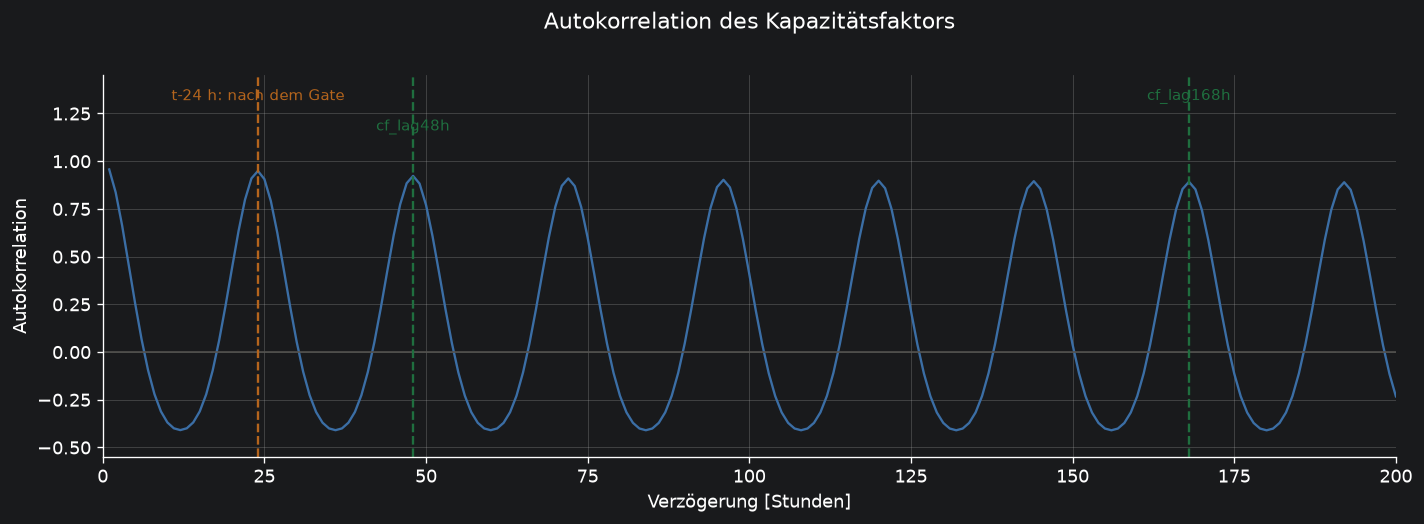

ACF bei 24 h: 0.949
ACF bei 48 h: 0.923
ACF bei 168 h: 0.892


In [11]:
def acf(series: pd.Series, lags: int) -> np.ndarray:
    """Sample autocorrelation of an evenly spaced series."""
    values = series.to_numpy() - series.to_numpy().mean()
    denominator = float((values**2).sum())
    return np.array(
        [(values[k:] * values[:-k]).sum() / denominator for k in range(1, lags + 1)]
    )


MAX_LAG = 200
correlation = acf(cf, MAX_LAG)
lags = np.arange(1, MAX_LAG + 1)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(lags, correlation, color="#3b6ea5", lw=1.4)
ax.axhline(0, color="#52514e", lw=1)

# Labels sit in the headroom above the curve so they stay readable
for lag, name, color, height in (
    (24, "t-24 h: nach dem Gate", "#b5651d", 1.34),
    (48, "cf_lag48h", "#1f6f3f", 1.18),
    (168, "cf_lag168h", "#1f6f3f", 1.34),
):
    ax.axvline(lag, color=color, ls="--", lw=1.4)
    ax.text(lag, height, name, ha="center", va="center", fontsize=9, color=color)

ax.set_xlabel("Verzögerung [Stunden]")
ax.set_ylabel("Autokorrelation")
ax.set_title("Autokorrelation des Kapazitätsfaktors", pad=28)
ax.set_xlim(0, MAX_LAG)
ax.set_ylim(-0.55, 1.45)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_autokorrelation.png")
plt.show()

print(f"ACF bei 24 h: {correlation[23]:.3f}")
print(f"ACF bei 48 h: {correlation[47]:.3f}")
print(f"ACF bei 168 h: {correlation[167]:.3f}")

## Features of stage S3

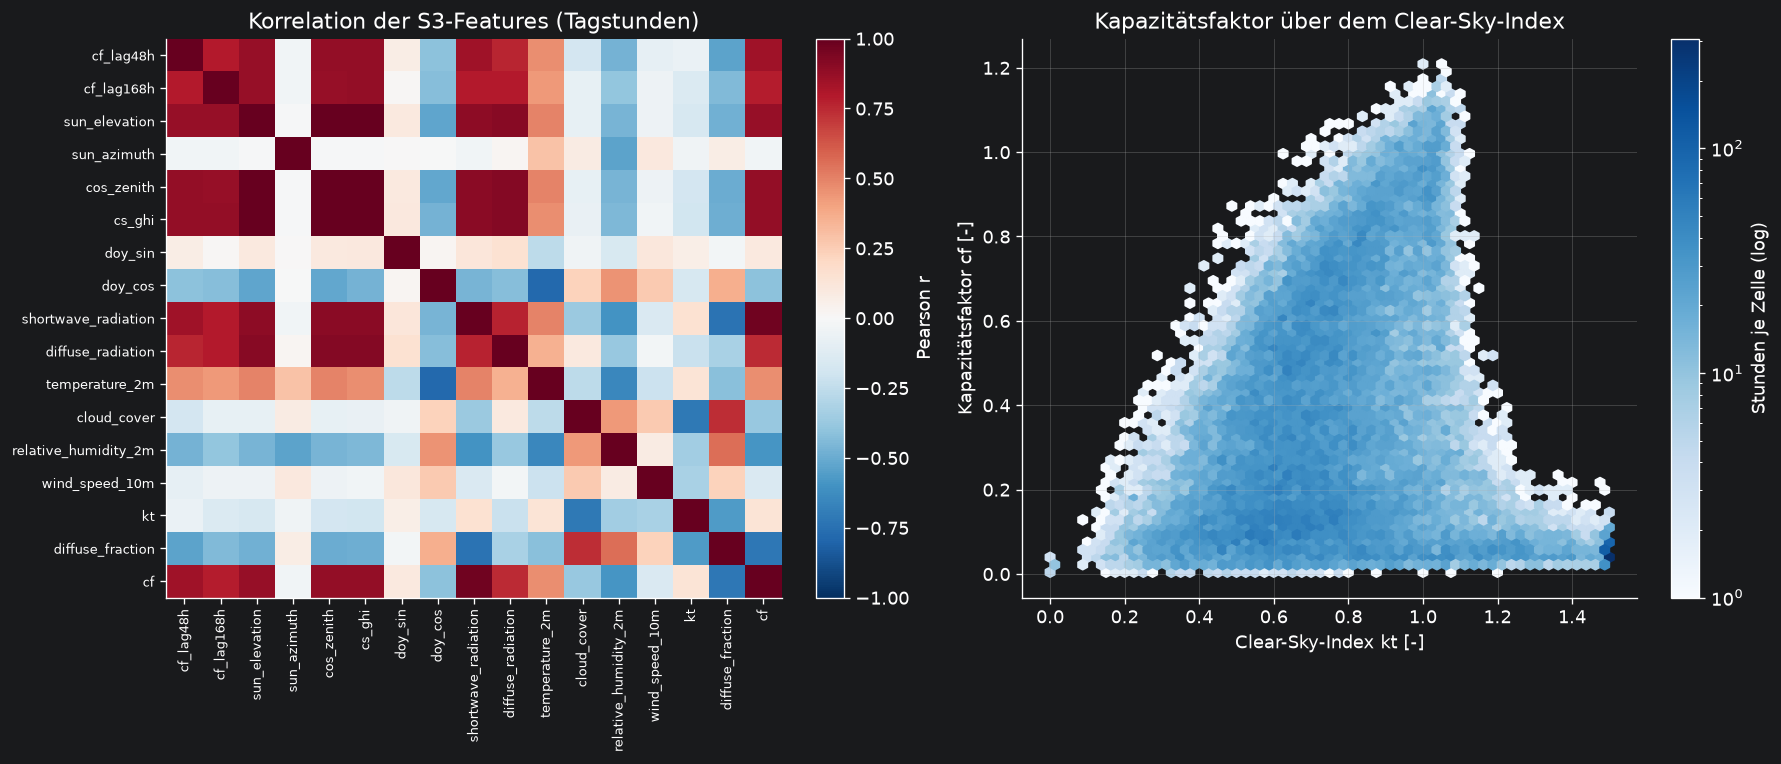

Stärkste Korrelation mit cf:
shortwave_radiation     0.970
cs_ghi                  0.879
cos_zenith              0.877
sun_elevation           0.871
cf_lag48h               0.846
cf_lag168h              0.784
diffuse_radiation       0.743
diffuse_fraction        0.724
relative_humidity_2m    0.590
temperature_2m          0.468
doy_cos                 0.407
cloud_cover             0.381
wind_speed_10m          0.156
kt                      0.134
doy_sin                 0.101
sun_azimuth             0.037


In [12]:
daylight = evaluation.daylight_mask(X["sun_elevation"])
stage = preprocessing.select(X, "S3").loc[daylight].assign(cf=cf.loc[daylight])
correlations = stage.corr()

fig, (ax_corr, ax_kt) = plt.subplots(1, 2, figsize=(15, 6.5))

mesh = ax_corr.pcolormesh(correlations.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax_corr.set_xticks(np.arange(len(correlations)) + 0.5)
ax_corr.set_yticks(np.arange(len(correlations)) + 0.5)
ax_corr.set_xticklabels(correlations.columns, rotation=90, fontsize=8)
ax_corr.set_yticklabels(correlations.index, fontsize=8)
ax_corr.invert_yaxis()
ax_corr.grid(False)
ax_corr.set_title("Korrelation der S3-Features (Tagstunden)")
fig.colorbar(mesh, ax=ax_corr, fraction=0.046).set_label("Pearson r")

hexes = ax_kt.hexbin(
    stage["kt"], stage["cf"], gridsize=60, bins="log", mincnt=1, cmap="Blues"
)
ax_kt.set_xlabel("Clear-Sky-Index kt [-]")
ax_kt.set_ylabel("Kapazitätsfaktor cf [-]")
ax_kt.set_title("Kapazitätsfaktor über dem Clear-Sky-Index")
fig.colorbar(hexes, ax=ax_kt, fraction=0.046).set_label("Stunden je Zelle (log)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_features.png")
plt.show()

print("Stärkste Korrelation mit cf:")
print(
    correlations["cf"]
    .drop("cf")
    .abs()
    .sort_values(ascending=False)
    .round(3)
    .to_string()
)

## Outliers and edge cases

In [13]:
cf_day = cf[daylight]
kt_day = X.loc[daylight, "kt"]

print(f"Tagstunden: {len(cf_day):,}")
print(f"cf > 1 (Einspeisung über der Kapazitätsschätzung): {(cf_day > 1).sum()}")
print(f"cf == 0 am Tag: {(cf_day == 0).sum()}")
print(f"kt am Cap ({preprocessing.KT_MAX}): {(kt_day >= preprocessing.KT_MAX).sum()}")
quantiles = cf_day.quantile([0.01, 0.25, 0.5, 0.75, 0.99]).round(4)
print(f"\nQuantile von cf (Tagstunden):\n{quantiles.to_string()}")

extreme = cf_day.nlargest(5)
print(f"\nHöchste Kapazitätsfaktoren:\n{extreme.round(3).to_string()}")

Tagstunden: 39,939
cf > 1 (Einspeisung über der Kapazitätsschätzung): 812
cf == 0 am Tag: 0
kt am Cap (1.5): 558

Quantile von cf (Tagstunden):
0.01    0.0220
0.25    0.1357
0.50    0.3268
0.75    0.5966
0.99    1.0469

Höchste Kapazitätsfaktoren:
time
2024-06-25 11:00:00+00:00    1.209
2021-04-27 11:00:00+00:00    1.203
2024-06-25 10:00:00+00:00    1.200
2021-04-27 10:00:00+00:00    1.199
2016-05-06 11:00:00+00:00    1.179
